In [2]:
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy.stats import entropy

In [5]:
pred_matrix = np.loadtxt("final_preds.txt", dtype=int)
true_matrix = np.loadtxt("../../../dataset/final_dataset1/drug_se_mat.txt", dtype=int)

pred_matrix.shape, true_matrix.shape

((1177, 4247), (1177, 4247))

In [7]:
# === Compute ADR counts per drug ===
adr_counts_pred = pred_matrix.sum(axis=1)
adr_counts_true = true_matrix.sum(axis=1)

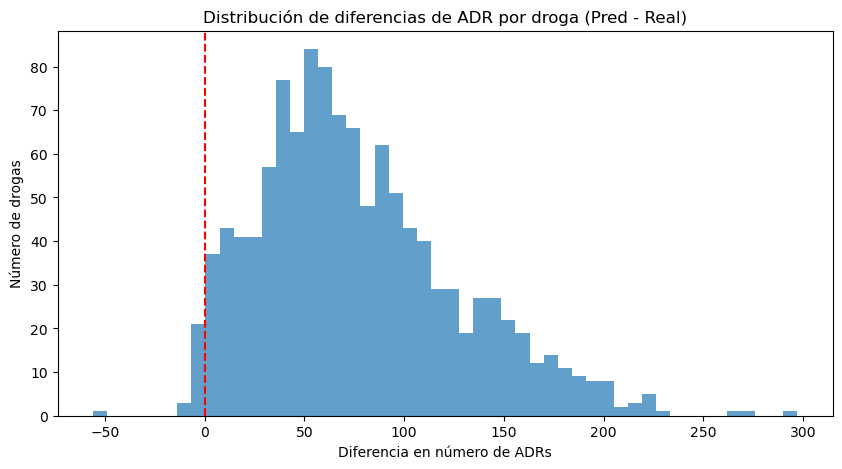

In [8]:
diff_counts = adr_counts_pred - adr_counts_true

plt.figure(figsize=(10, 5))
plt.hist(diff_counts, bins=50, alpha=0.7)
plt.title("Distribución de diferencias de ADR por droga (Pred - Real)")
plt.xlabel("Diferencia en número de ADRs")
plt.ylabel("Número de drogas")
plt.axvline(0, color="red", linestyle="--")
plt.show()


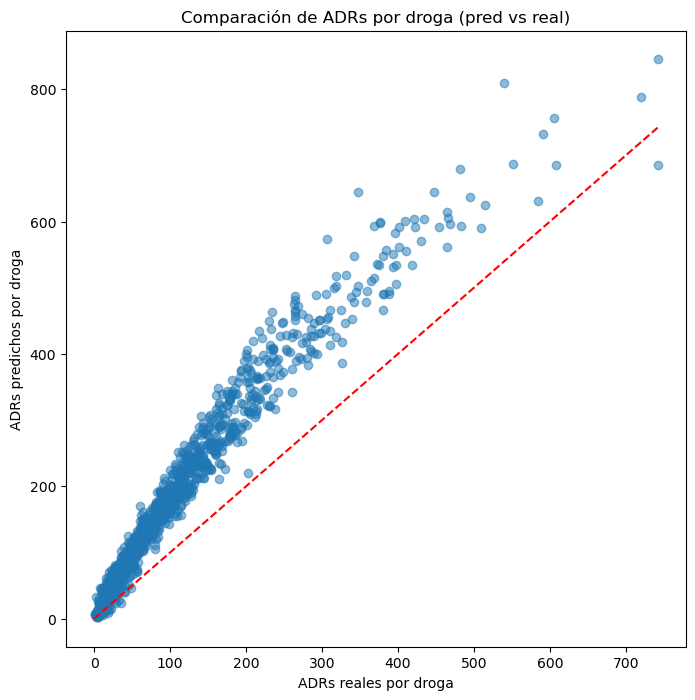

In [9]:
plt.figure(figsize=(8, 8))
plt.scatter(adr_counts_true, adr_counts_pred, alpha=0.5)
plt.plot([0, adr_counts_true.max()], [0, adr_counts_true.max()], 'r--')
plt.xlabel("ADRs reales por droga")
plt.ylabel("ADRs predichos por droga")
plt.title("Comparación de ADRs por droga (pred vs real)")
plt.show()


In [10]:
# Convertir a distribución de probabilidad (sum = 1)
p_true = adr_counts_true / adr_counts_true.sum()
p_pred = adr_counts_pred / adr_counts_pred.sum()

# Pequeño epsilon para evitar log(0)
eps = 1e-10
p_true = np.clip(p_true, eps, 1)
p_pred = np.clip(p_pred, eps, 1)

kl_div = entropy(p_true, p_pred)  # KL(true || pred)
print(f"KL Divergence (True || Pred): {kl_div:.6f}")


KL Divergence (True || Pred): 0.018089


In [ ]:
m = 0.5 * (p_true + p_pred)
js_div = 0.5 * (entropy(p_true, m) + entropy(p_pred, m))
print(f"Jensen–Shannon Divergence: {js_div:.6f}")

Jensen–Shannon Divergence: 0.004493


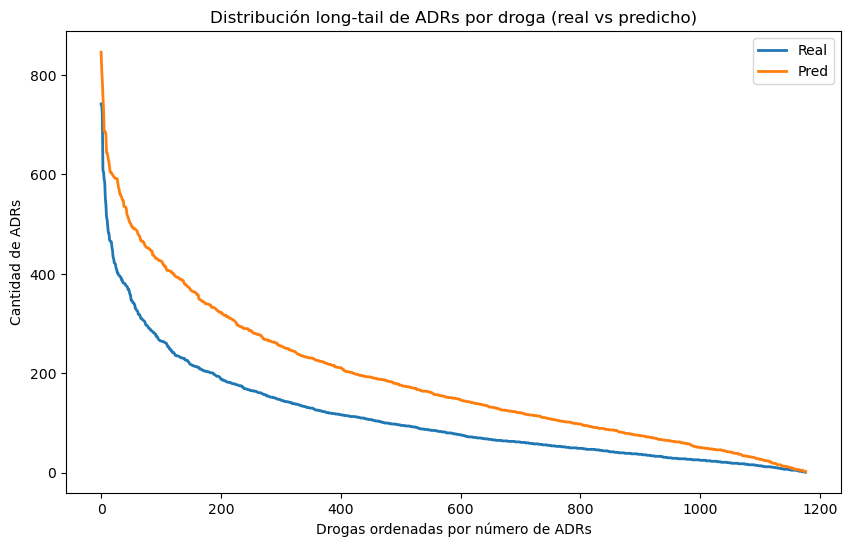

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(np.sort(adr_counts_true)[::-1], label="Real", lw=2)
plt.plot(np.sort(adr_counts_pred)[::-1], label="Pred", lw=2)
plt.title("Distribución long-tail de ADRs por droga (real vs predicho)")
plt.xlabel("Drogas ordenadas por número de ADRs")
plt.ylabel("Cantidad de ADRs")
plt.legend()
plt.show()
